# Exploratory NISAR BETA GSLC interferometry near Chilpancingo, Mexico

## Abstract

This notebook forms four approximately 12-day interferograms from six NISAR L-band HH GSLC acquisitions acquired between 12 December 2025 and 10 January 2026. It estimates coherence using 4 × 4 block averaging on the geocoded north–east grid, unwraps the phase over a connected high-coherence component, removes a robust planar trend used as a local spatial reference, and converts the corrected phase to relative line-of-sight (LOS) range change. It also constructs diagnostic east–up products from ascending and descending observations under the explicit assumptions of zero northward displacement, approximate LOS geometry, and temporal compatibility between the two viewing directions. The M6.5 San Marcos, Guerrero earthquake occurred on 2 January 2026 at 07:58 local time (13:58 UTC); two interferometric pairs precede the event and two contain the event time [6].

The input granules are **pre-calibration NISAR BETA products**. NISAR documents [3] a misaligned valid-data mask, residual ionospheric signatures, radio-frequency interference, edge artifacts, incomplete calibration, and possible interferometric artifacts in this collection. Improved PROVISIONAL products have been available since July 2026, but NISAR notes that early acquisitions may remain available only as BETA products. Consequently, this workflow and its maps are suitable for transparent method development and hypothesis generation, **not as stand-alone geodetic evidence**.

The archived run also shows strong spatial correlation between the pre-event and event-spanning LOS maps (about 0.775 for both viewing directions). That control argues against attributing the entire event-spanning pattern to the earthquake without independent GNSS, atmospheric/ionospheric corrections, a demonstrably stable reference, and comparison with calibrated or official interferometric products.

The primary quantitative products are spatially dense maps of relative LOS displacement and apparent interval-mean LOS rate. These rates are obtained by dividing displacement by the acquisition interval; they are not velocities estimated from a geodetic time-series inversion. The event-spanning measurements combine pre-, co-, and post-event deformation and therefore do not isolate a coseismic or postseismic signal.


## Reproducibility and data availability

The six GSLC granules are not stored in this repository;
point `NISAR_GSLC_DIR` to them. The ROI shapefile is included under `ROI/`.

Core Python dependencies are `numpy`, `scipy`, `h5py`, `xarray`, `geopandas`,
`rasterio`, `pyproj`, `scikit-image`, and `matplotlib`. The notebook intentionally fails
with explicit messages when required inputs, CRS metadata, wavelength metadata, or grid
compatibility are missing.


## 0. Definitions, decisions, and sign conventions

1. The interferogram is formed as $z_1z_2^*$ (`reference * conj(secondary)`), matching the ISCE3 `Crossmul` implementation [5].
2. For an SLC phase proportional to $-4\pi R/\lambda$, this convention yields $\Delta R=R_2-R_1=\lambda\Delta\phi/(4\pi)$. Positive LOS therefore denotes increasing range, or motion **away from the satellite**.
3. Coherence after 4 × 4 block averaging on the geocoded north–east grid is estimated from the complex moments, is estimated from the complex moments, $|\langle z_1z_2^*\rangle|/\sqrt{\langle|z_1|^2\rangle\langle|z_2|^2\rangle}$; precomputed coherence values are not averaged [7–9]. The 4 × 4 operation averages neighboring geocoded pixels; it must not be interpreted as four independent azimuth looks and four independent slant-range looks.
4. Phase is unwrapped only inside the connected valid component with the greatest ROI overlap. Missing pixels are never filled with zero phase.
5. A robust planar trend is estimated after phase unwrapping and used for local spatial referencing. This operation removes the best-fitting long-wavelength planar component but does not demonstrate that orbital or atmospheric errors have been physically corrected.
6. LOS vectors come from each GSLC metadata cube. In the archived run no ellipsoidal DEMwas supplied, so height layers were averaged and their component span was retained as a geometry-sensitivity diagnostic. NISAR recommends three-dimensional interpolation [2] at the actual ellipsoidal surface height; the layer average is an approximation.
7. Two LOS measurements cannot determine three displacement components. The 2-D inversion fixes north displacement to zero and reports the east/up bias caused by a 1 cm omitted north component [12,13].
8. The event-spanning pairs mix pre-, co-, and post-event motion. Their interval mean is not a postseismic velocity, and the conditional 2-D displacement is a The conditional 2-D displacement is only an event-spanning diagnostic under the explicit temporal assumptions stated below; it is not an independently identified coseismic displacement. only under the explicit temporal assumptions stated below.


## Scientific audit summary

| Element | Assessment | Publication implication |
|---|---|---|
| GSLC cross-multiplication and beta0 | Supported by the NISAR GSLC guide and ISCE3 implementation | Method is correct when grids and wavelengths match |
| Moment-based coherence | Standard estimator | The 4×4 sample count is not an effective-look estimate |
| Coherence-derived phase precision | Nominal decorrelation-precision diagnostic computed under an independent-look approximation | Because 16 independent looks have not been demonstrated, this diagnostic is not a quantitative lower bound or a complete uncertainty estimate. |
| Reliability-sorting phase unwrapping | Established algorithm with explicit masking | Must be checked against an InSAR-specific network-flow solution/GUNW for scientific use |
| Planar detrending and local referencing | Common and auditable | Candidate pixels outside the ROI are not proven stable and can remove real signal |
| LOS metadata vectors | Definitions and signs match NISAR documentation | Archived height-layer averaging is approximate; supply an ellipsoidal DEM for 3-D interpolation |
| East/up decomposition | Linear algebra and sign are correct | It is conditional on $N=0$, temporal compatibility, and compatible spatial references |
| Wrapped triplet closure | Useful consistency diagnostic | Nonzero closure can be physical/decorrelation-driven; it is not a binary pass/fail test |
| Earthquake attribution | Not established by this notebook | Strong pre/event spatial similarity and unmodelled systematics require independent validation |


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import os
import re
import warnings

import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import xarray as xr
from affine import Affine
from pyproj import CRS
from rasterio.features import geometry_mask
from rasterio.warp import Resampling, reproject
from scipy import ndimage
from scipy.interpolate import RegularGridInterpolator
from skimage.restoration import unwrap_phase

warnings.filterwarnings("default")

# Run from the Processing directory, or set CHILPANCINGO_PROCESSING_DIR explicitly.
PROCESSING_DIR = Path("/home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing")
DATA_DIR = Path(os.environ.get("NISAR_GSLC_DIR", "/mnt/data-r1/data/NISAR/Chilpancingo"))
ROI_FILE = Path(os.environ.get("CHILPANCINGO_ROI", str(PROCESSING_DIR / "ROI" / "chilpancingo_norponiente.shp")))
OUT_DIR = Path(os.environ.get("CHILPANCINGO_RESULTS_DIR", str(PROCESSING_DIR / "Results")))
NC_DIR = OUT_DIR / "nc"
FIGURE_DIR = OUT_DIR / "Figures"
REFERENCE_FILE_ENV = os.environ.get("CHILPANCINGO_STABLE_REFERENCE", "")
REFERENCE_FILE = Path(REFERENCE_FILE_ENV) if REFERENCE_FILE_ENV else None

reference_file_env = os.environ.get("CHILPANCINGO_STABLE_REFERENCE", "")
REFERENCE_FILE = Path(reference_file_env).expanduser().resolve() if reference_file_env else None
dem_file_env = os.environ.get("CHILPANCINGO_ELLIPSOIDAL_DEM", "")
ELLIPSOIDAL_DEM_FILE = Path(dem_file_env).expanduser().resolve() if dem_file_env else None

POLARIZATION = "HH"
LOOK_Y, LOOK_X = 4, 4          # Nominal 5 m posting to 20 m; not 16 independent looks.
COHERENCE_THRESHOLD = 0.30     # Analysis parameter, not an official NISAR threshold.
COHERENCE_SENSITIVITY = (0.20, 0.30, 0.40, 0.50)
CONTEXT_BUFFER_M = 5_000.0     # Computational context, not a geophysical constant.
REFERENCE_EXCLUSION_M = 1_000.0
REFERENCE_EXCLUSION_SENSITIVITY_M = (500.0, 1_000.0, 1_500.0)
RAMP_MODE = "external_polygon" if REFERENCE_FILE else "outside_roi_candidate"
HUBER_K = 1.345                # Standard Huber tuning constant (~95% Gaussian efficiency).
EVENT_TIME = datetime(2026, 1, 2, 13, 58, 15, tzinfo=timezone.utc)
C_LIGHT = 299_792_458.0

for directory in (OUT_DIR, NC_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

PAIRS = {
    "pre_desc": {
        "reference": "NISAR_L2_PR_GSLC_007_113_D_080_4005_DHDH_A_20251212T011405_20251212T011427_X05010_N_P_J_001.h5",
        "secondary": "NISAR_L2_PR_GSLC_008_113_D_080_4005_DHDH_A_20251224T011405_20251224T011428_X05010_N_P_J_001.h5",
        "start": "2025-12-12T01:14:05Z", "end": "2025-12-24T01:14:05Z",
        "track": 113, "orbit": "descending", "class": "pre_event",
    },
    "pre_asc": {
        "reference": "NISAR_L2_PR_GSLC_008_019_A_010_4005_DHDH_A_20251217T120507_20251217T120542_X05009_N_F_J_001.h5",
        "secondary": "NISAR_L2_PR_GSLC_009_019_A_010_4005_DHDH_A_20251229T120508_20251229T120542_X05009_N_F_J_001.h5",
        "start": "2025-12-17T12:05:07Z", "end": "2025-12-29T12:05:08Z",
        "track": 19, "orbit": "ascending", "class": "pre_event",
    },
    "event_desc": {
        "reference": "NISAR_L2_PR_GSLC_008_113_D_080_4005_DHDH_A_20251224T011405_20251224T011428_X05010_N_P_J_001.h5",
        "secondary": "NISAR_L2_PR_GSLC_009_113_D_080_4005_DHDH_A_20260105T011406_20260105T011429_X05010_N_P_J_001.h5",
        "start": "2025-12-24T01:14:05Z", "end": "2026-01-05T01:14:06Z",
        "track": 113, "orbit": "descending", "class": "event_spanning",
    },
    "event_asc": {
        "reference": "NISAR_L2_PR_GSLC_009_019_A_010_4005_DHDH_A_20251229T120508_20251229T120542_X05009_N_F_J_001.h5",
        "secondary": "NISAR_L2_PR_GSLC_010_019_A_010_4005_DHDH_A_20260110T120508_20260110T120543_X05009_N_F_J_001.h5",
        "start": "2025-12-29T12:05:08Z", "end": "2026-01-10T12:05:08Z",
        "track": 19, "orbit": "ascending", "class": "event_spanning",
    },
}

for pair in PAIRS.values():
    pair["start_dt"] = datetime.fromisoformat(pair["start"].replace("Z", "+00:00"))
    pair["end_dt"] = datetime.fromisoformat(pair["end"].replace("Z", "+00:00"))
    pair["duration_days"] = (pair["end_dt"] - pair["start_dt"]).total_seconds() / 86400.0
    if pair["class"] == "pre_event":
        assert pair["end_dt"] < EVENT_TIME
    else:
        assert pair["start_dt"] < EVENT_TIME < pair["end_dt"]


## 1. Input discovery and metadata validation


In [2]:
def _scalar_dataset_paths(h5, token):
    found = []
    token = token.lower()

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset) and obj.shape in ((), (1,)) and token in name.lower():
            found.append(name)

    h5.visititems(visitor)
    return found


def read_epsg(path):
    candidates = (
        "/science/LSAR/GSLC/grids/frequencyA/projection",
        "/science/LSAR/GSLC/metadata/radarGrid/projection",
    )
    with h5py.File(path, "r") as h5:
        for key in candidates:
            if key in h5:
                return int(np.asarray(h5[key][()]).squeeze())
    raise KeyError(f"Official EPSG code not found in {path.name}")


def read_wavelength(path):
    with h5py.File(path, "r") as h5:
        paths = _scalar_dataset_paths(h5, "centerfrequency")
        values = []
        for key in paths:
            value = float(np.asarray(h5[key][()]).squeeze())
            if 1e8 < value < 2e9:
                values.append((key, value))
        # The workflow reads frequencyA/HH, so frequencyA metadata are preferred.
        values_a = [(key, value) for key, value in values if "frequencya" in key.lower().replace("_", "")]
        selected = values_a if values_a else values
        unique = np.unique([value for _, value in selected])
        if len(unique) == 1:
            return C_LIGHT / unique[0], f"HDF5:{selected[0][0]}"
    raise KeyError(f"Frequency A could not be determined unambiguously from {path.name}")


def filename_time(path):
    match = re.search(r"_(\d{8}T\d{6})_", path.name)
    if not match:
        raise ValueError(f"Acquisition time not found in {path.name}")
    return datetime.strptime(match.group(1), "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)


all_names = sorted({pair[key] for pair in PAIRS.values() for key in ("reference", "secondary")})
all_files = {name: DATA_DIR / name for name in all_names}
missing = [str(path) for path in all_files.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing GSLC inputs. Set NISAR_GSLC_DIR. Files not found:\n  " + "\n  ".join(missing)
    )
if not ROI_FILE.is_file():
    raise FileNotFoundError("ROI file not found. Set CHILPANCINGO_ROI: " + str(ROI_FILE))
if REFERENCE_FILE is not None and not REFERENCE_FILE.is_file():
    raise FileNotFoundError("Stable-reference file not found: " + str(REFERENCE_FILE))
if ELLIPSOIDAL_DEM_FILE is not None and not ELLIPSOIDAL_DEM_FILE.is_file():
    raise FileNotFoundError("Ellipsoidal DEM not found: " + str(ELLIPSOIDAL_DEM_FILE))

epsgs = {read_epsg(path) for path in all_files.values()}
if len(epsgs) != 1:
    raise ValueError(f"The six GSLCs do not share one CRS: {epsgs}")
EPSG = epsgs.pop()

for name, path in all_files.items():
    print(filename_time(path).isoformat(), path.name)
print("Common CRS:", CRS.from_epsg(EPSG))
print("Product maturity: pre-calibration NISAR BETA; exploratory use only.")


2025-12-12T01:14:05+00:00 NISAR_L2_PR_GSLC_007_113_D_080_4005_DHDH_A_20251212T011405_20251212T011427_X05010_N_P_J_001.h5
2025-12-17T12:05:07+00:00 NISAR_L2_PR_GSLC_008_019_A_010_4005_DHDH_A_20251217T120507_20251217T120542_X05009_N_F_J_001.h5
2025-12-24T01:14:05+00:00 NISAR_L2_PR_GSLC_008_113_D_080_4005_DHDH_A_20251224T011405_20251224T011428_X05010_N_P_J_001.h5
2025-12-29T12:05:08+00:00 NISAR_L2_PR_GSLC_009_019_A_010_4005_DHDH_A_20251229T120508_20251229T120542_X05009_N_F_J_001.h5
2026-01-05T01:14:06+00:00 NISAR_L2_PR_GSLC_009_113_D_080_4005_DHDH_A_20260105T011406_20260105T011429_X05010_N_P_J_001.h5
2026-01-10T12:05:08+00:00 NISAR_L2_PR_GSLC_010_019_A_010_4005_DHDH_A_20260110T120508_20260110T120543_X05009_N_F_J_001.h5
Common CRS: EPSG:32614
Product maturity: pre-calibration NISAR BETA; exploratory use only.


## 2. Exact spatial subset and ROI mask

The ROI geometry is reprojected into the product CRS, and a surrounding context window
is retained for reference estimation. Results are masked by the polygon rather than by
its rectangular bounds. Because NISAR documents a BETA valid-mask misalignment, the
primary validity test here uses finite, nonzero complex samples. The official mask is
reported as a diagnostic but is not applied by default. This workaround does not
guarantee removal of all edge artifacts.


In [3]:
GRID = "/science/LSAR/GSLC/grids/frequencyA"
RADAR_GRID = "/science/LSAR/GSLC/metadata/radarGrid"


def index_slice(coords, low, high):
    coords = np.asarray(coords)
    selected = np.flatnonzero((coords >= low) & (coords <= high))
    if selected.size == 0:
        raise ValueError(f"The subset [{low}, {high}] does not intersect the grid.")
    return slice(int(selected[0]), int(selected[-1]) + 1)


def read_subset(path, bounds, pol=POLARIZATION):
    with h5py.File(path, "r") as h5:
        x = np.asarray(h5[f"{GRID}/xCoordinates"][:], dtype=float)
        y = np.asarray(h5[f"{GRID}/yCoordinates"][:], dtype=float)
        sx = index_slice(x, bounds[0], bounds[2])
        sy = index_slice(y, bounds[1], bounds[3])
        slc = np.asarray(h5[f"{GRID}/{pol}"][sy, sx])
        official_mask = None
        mask_path = f"{GRID}/mask"
        if mask_path in h5:
            official_mask = np.asarray(h5[mask_path][sy, sx])
    valid_empirical = np.isfinite(slc.real) & np.isfinite(slc.imag) & (np.abs(slc) > 0)
    wavelength, wavelength_source = read_wavelength(path)
    return {
        "slc": slc, "x": x[sx], "y": y[sy], "valid": valid_empirical,
        "official_mask": official_mask, "wavelength_m": wavelength,
        "wavelength_source": wavelength_source, "file": str(path),
    }


def affine_from_centers(x, y):
    if len(x) < 2 or len(y) < 2:
        raise ValueError("The grid requires at least two coordinates per dimension.")
    dx = float(np.median(np.diff(x)))
    dy = float(np.median(np.diff(y)))
    return Affine(dx, 0.0, float(x[0] - dx / 2), 0.0, dy, float(y[0] - dy / 2))


def rasterize_gdf(gdf, x, y):
    return geometry_mask(
        [geom.__geo_interface__ for geom in gdf.geometry if geom is not None],
        out_shape=(len(y), len(x)), transform=affine_from_centers(x, y),
        invert=True, all_touched=False,
    )


roi = gpd.read_file(ROI_FILE)
if roi.crs is None:
    raise ValueError("The ROI file has no declared CRS; none is guessed.")
roi = roi.to_crs(EPSG)
if roi.empty or roi.geometry.is_empty.all():
    raise ValueError("The ROI contains no valid geometry.")

minx, miny, maxx, maxy = roi.total_bounds
analysis_bounds = (minx - CONTEXT_BUFFER_M, miny - CONTEXT_BUFFER_M,
                   maxx + CONTEXT_BUFFER_M, maxy + CONTEXT_BUFFER_M)

acquisitions = {name: read_subset(path, analysis_bounds) for name, path in all_files.items()}
for name, acq in acquisitions.items():
    print(name, acq["slc"].shape, f"lambda={acq['wavelength_m']:.9f} m", acq["wavelength_source"])
    if acq["official_mask"] is not None:
        codes = np.unique(acq["official_mask"])
        print("  official BETA mask present; codes:", codes[:20], "(not applied because of the documented alignment issue)")


NISAR_L2_PR_GSLC_007_113_D_080_4005_DHDH_A_20251212T011405_20251212T011427_X05010_N_P_J_001.h5 (2322, 2355) lambda=0.241963243 m HDF5:science/LSAR/GSLC/grids/frequencyA/centerFrequency
  official BETA mask present; codes: [1] (not applied because of the documented alignment issue)
NISAR_L2_PR_GSLC_008_019_A_010_4005_DHDH_A_20251217T120507_20251217T120542_X05009_N_F_J_001.h5 (2322, 2355) lambda=0.241963243 m HDF5:science/LSAR/GSLC/grids/frequencyA/centerFrequency
  official BETA mask present; codes: [1] (not applied because of the documented alignment issue)
NISAR_L2_PR_GSLC_008_113_D_080_4005_DHDH_A_20251224T011405_20251224T011428_X05010_N_P_J_001.h5 (2322, 2355) lambda=0.241963243 m HDF5:science/LSAR/GSLC/grids/frequencyA/centerFrequency
  official BETA mask present; codes: [1] (not applied because of the documented alignment issue)
NISAR_L2_PR_GSLC_009_019_A_010_4005_DHDH_A_20251229T120508_20251229T120542_X05009_N_F_J_001.h5 (2322, 2355) lambda=0.241963243 m HDF5:science/LSAR/GSLC/gr

## 3. Geocoded 4 × 4 block averaging, coherence, and masked phase unwrapping

A nominal decorrelation-only phase-precision diagnostic is calculated as

$$\sigma_\phi \simeq \sqrt{\frac{1-\gamma^2}{2L\gamma^2}}$$

This expression is standard under assumptions that include statistically independent looks. Here, \(L=16\) is only the number of geocoded samples in a 4 × 4 block; an effective number of independent looks has not been estimated. Because neighboring GSLC samples can be correlated, the resulting value must be interpreted only as an optimistic nominal diagnostic, not as a demonstrated Cramér–Rao lower bound or a complete uncertainty estimate. Atmospheric, ionospheric, orbital, reference, residual-topography, filtering, and unwrapping errors are excluded [8,9].

In [4]:
def block_mean(array, ly=LOOK_Y, lx=LOOK_X):
    ny = array.shape[0] - array.shape[0] % ly
    nx = array.shape[1] - array.shape[1] % lx
    return array[:ny, :nx].reshape(ny // ly, ly, nx // lx, lx).mean(axis=(1, 3))


def block_all(mask, ly=LOOK_Y, lx=LOOK_X):
    ny = mask.shape[0] - mask.shape[0] % ly
    nx = mask.shape[1] - mask.shape[1] % lx
    return mask[:ny, :nx].reshape(ny // ly, ly, nx // lx, lx).all(axis=(1, 3))


def block_coords(coords, look):
    n = len(coords) - len(coords) % look
    return np.asarray(coords[:n]).reshape(-1, look).mean(axis=1)


def choose_connected_component(valid, roi_mask):
    labels, nlabels = ndimage.label(valid, structure=np.ones((3, 3), dtype=int))
    if nlabels == 0:
        raise ValueError("No coherent connected component is available for unwrapping.")
    overlap = np.bincount(labels[roi_mask & valid], minlength=nlabels + 1)
    overlap[0] = 0
    if overlap.max() > 0:
        label = int(overlap.argmax())
    else:
        size = np.bincount(labels.ravel(), minlength=nlabels + 1)
        size[0] = 0
        label = int(size.argmax())
    return labels == label, labels, label


def masked_unwrap(wrapped, valid, roi_mask):
    selected, labels, selected_label = choose_connected_component(valid, roi_mask)
    masked = np.ma.array(wrapped, mask=~selected)
    unwrapped = unwrap_phase(masked, wrap_around=False, rng=0)
    return np.asarray(unwrapped.filled(np.nan), dtype=float), selected, labels, selected_label


def nominal_phase_sigma(coherence, nominal_samples=LOOK_Y * LOOK_X):
    gamma = np.asarray(coherence, dtype=float)
    out = np.full_like(gamma, np.nan)
    ok = (gamma > 0) & (gamma <= 1)
    out[ok] = np.sqrt((1.0 - gamma[ok] ** 2) /
                      (2.0 * nominal_samples * gamma[ok] ** 2))
    return out


def form_interferogram(reference, secondary, roi_gdf):
    if not np.array_equal(reference["x"], secondary["x"]) or not np.array_equal(reference["y"], secondary["y"]):
        raise ValueError("Pair acquisitions do not share an identical grid; shape truncation is not allowed.")
    if not np.isclose(reference["wavelength_m"], secondary["wavelength_m"], rtol=0, atol=1e-12):
        raise ValueError("Pair wavelengths do not match.")

    z1, z2 = reference["slc"], secondary["slc"]
    valid_full = reference["valid"] & secondary["valid"]
    cross_ml = block_mean(z1 * np.conj(z2))
    p1_ml = block_mean(np.abs(z1) ** 2)
    p2_ml = block_mean(np.abs(z2) ** 2)
    valid_ml = block_all(valid_full) & (p1_ml > 0) & (p2_ml > 0)
    coherence = np.full(p1_ml.shape, np.nan, dtype=float)
    coherence[valid_ml] = np.abs(cross_ml[valid_ml]) / np.sqrt(p1_ml[valid_ml] * p2_ml[valid_ml])
    coherence = np.clip(coherence, 0.0, 1.0)
    wrapped = np.angle(cross_ml)
    x_ml = block_coords(reference["x"], LOOK_X)
    y_ml = block_coords(reference["y"], LOOK_Y)
    roi_ml = rasterize_gdf(roi_gdf, x_ml, y_ml)
    unwrap_valid = valid_ml & np.isfinite(coherence) & (coherence >= COHERENCE_THRESHOLD)
    unwrapped, component, labels, selected_label = masked_unwrap(wrapped, unwrap_valid, roi_ml)
    phase_sigma = nominal_phase_sigma(coherence)
    return {
        "x": x_ml, "y": y_ml, "wrapped": wrapped, "unwrapped": unwrapped,
        "coherence": coherence, "beta0_reference": p1_ml, "beta0_secondary": p2_ml,
        "valid": valid_ml, "unwrap_component": component, "component_labels": labels,
        "selected_label": selected_label, "roi": roi_ml,
        "phase_sigma_lower_rad": phase_sigma,
        "wavelength_m": reference["wavelength_m"],
    }


## 4. Local spatial reference and planar detrending

Coherent pixels located outside the buffered ROI are used only as candidate reference pixels; their physical stability has not been independently demonstrated. The fitted plane defines a local relative reference and may absorb genuine long-wavelength deformation or propagation-delay signals. Therefore, planar detrending must not be described as a demonstrated orbital or atmospheric correction.

In [5]:
def huber_plane(x, y, phase, mask, k=HUBER_K, max_iter=30):
    finite = mask & np.isfinite(phase)
    if finite.sum() < 20:
        raise ValueError("Fewer than 20 reference pixels; the plane is not verifiable.")
    xc = float(np.nanmedian(x))
    yc = float(np.nanmedian(y))
    xx, yy = np.meshgrid((x - xc) / 1000.0, (y - yc) / 1000.0)
    A = np.column_stack([xx[finite], yy[finite], np.ones(finite.sum())])
    b = phase[finite]
    if np.linalg.matrix_rank(A) < 3:
        raise ValueError("The reference has insufficient two-dimensional extent for a plane.")
    w = np.ones_like(b)
    coef = np.linalg.lstsq(A, b, rcond=None)[0]
    for _ in range(max_iter):
        old = coef.copy()
        residual = b - A @ coef
        scale = 1.4826 * np.median(np.abs(residual - np.median(residual)))
        if not np.isfinite(scale) or scale == 0:
            break
        u = np.abs(residual) / (k * scale)
        w = np.ones_like(u)
        high = u > 1
        w[high] = 1.0 / u[high]
        coef = np.linalg.lstsq(A * np.sqrt(w[:, None]), b * np.sqrt(w), rcond=None)[0]
        if np.max(np.abs(coef - old)) < 1e-10:
            break
    plane = coef[0] * xx + coef[1] * yy + coef[2]
    corrected = phase - plane
    final_residual = corrected[finite]
    sigma = 1.4826 * np.median(np.abs(final_residual - np.median(final_residual)))
    return corrected, plane, coef, sigma, finite


def reference_mask_for(result, exclusion_m=REFERENCE_EXCLUSION_M):
    base = result["unwrap_component"]
    if RAMP_MODE == "external_polygon":
        ref = gpd.read_file(REFERENCE_FILE)
        if ref.crs is None:
            raise ValueError("The stable-reference polygon has no declared CRS.")
        ref = ref.to_crs(EPSG)
        mask = rasterize_gdf(ref, result["x"], result["y"])
    elif RAMP_MODE == "outside_roi_candidate":
        outside = gpd.GeoDataFrame(geometry=roi.geometry.buffer(exclusion_m), crs=roi.crs)
        mask = ~rasterize_gdf(outside, result["x"], result["y"])
    else:
        raise ValueError(f"Unrecognized RAMP_MODE: {RAMP_MODE}")
    return base & mask & np.isfinite(result["coherence"]) & (result["coherence"] >= COHERENCE_THRESHOLD)


def apply_ramp_and_los(result, exclusion_m=REFERENCE_EXCLUSION_M):
    reference_mask = reference_mask_for(result, exclusion_m)
    corrected, plane, coef, ramp_sigma_rad, used = huber_plane(
        result["x"], result["y"], result["unwrapped"], reference_mask
    )
    wavelength = result["wavelength_m"]
    los_cm = corrected * wavelength / (4.0 * np.pi) * 100.0
    sigma_cm = result["phase_sigma_lower_rad"] * wavelength / (4.0 * np.pi) * 100.0
    result.update({
        "ramp_phase": plane, "phase_corrected": corrected,
        "los_away_cm": los_cm, "los_rate_away_cm_day": None,
        "los_sigma_lower_cm": sigma_cm, "reference_mask": used,
        "ramp_coeff_rad_per_km_x_y_intercept": coef,
        "reference_residual_mad_sigma_rad": ramp_sigma_rad,
        "reference_exclusion_m": float(exclusion_m),
    })
    return result


## 5. Per-pixel LOS geometry from the official metadata cube

`losUnitVectorX` and `losUnitVectorY` are the east and north components of the unit vector from target to sensor; the positive up component is derived from unit length. NISAR recommends three-dimensional interpolation over ellipsoidal height, northing, and easting. This notebook performs that interpolation if a compatible ellipsoidal DEM is provided through `CHILPANCINGO_ELLIPSOIDAL_DEM`. Otherwise, it reproduces the archived approximation by averaging all height layers and records the full component span across the cube. It never substitutes fixed incidence or heading angles. Consequently, results generated without an ellipsoidal DEM must label the LOS geometry as approximate. East–up decomposition based on the height-layer average is retained only as a sensitivity or diagnostic product and should not be presented as a definitive surface-displacement measurement.


In [6]:
def _ascending_axes(x, y, layer):
    x = np.asarray(x)
    y = np.asarray(y)
    layer = np.asarray(layer)
    if x[0] > x[-1]:
        x, layer = x[::-1], layer[:, ::-1]
    if y[0] > y[-1]:
        y, layer = y[::-1], layer[::-1, :]
    return x, y, layer


def interpolate_layer(x_src, y_src, layer, x_dst, y_dst):
    x_src, y_src, layer = _ascending_axes(x_src, y_src, layer)
    interp = RegularGridInterpolator((y_src, x_src), layer, bounds_error=False, fill_value=np.nan)
    xx, yy = np.meshgrid(x_dst, y_dst)
    points = np.column_stack([yy.ravel(), xx.ravel()])
    return interp(points).reshape(len(y_dst), len(x_dst))


def read_ellipsoidal_dem(path, x_dst, y_dst):
    """Reproject a user-supplied ellipsoidal-height DEM to the analysis grid."""
    destination = np.full((len(y_dst), len(x_dst)), np.nan, dtype=np.float32)
    with rasterio.open(path) as source:
        if source.crs is None:
            raise ValueError("The ellipsoidal DEM has no declared horizontal CRS.")
        reproject(
            source=rasterio.band(source, 1), destination=destination,
            src_transform=source.transform, src_crs=source.crs, src_nodata=source.nodata,
            dst_transform=affine_from_centers(x_dst, y_dst), dst_crs=CRS.from_epsg(EPSG),
            dst_nodata=np.nan, resampling=Resampling.bilinear,
        )
    if not np.isfinite(destination).any():
        raise ValueError("The ellipsoidal DEM does not overlap the analysis grid.")
    return destination


def _ascending_cube_axes(x, y, height, cube):
    x = np.asarray(x)
    y = np.asarray(y)
    height = np.asarray(height)
    cube = np.asarray(cube)
    if x[0] > x[-1]:
        x, cube = x[::-1], cube[:, :, ::-1]
    if y[0] > y[-1]:
        y, cube = y[::-1], cube[:, ::-1, :]
    if height[0] > height[-1]:
        height, cube = height[::-1], cube[::-1, :, :]
    return x, y, height, cube


def interpolate_cube_at_height(x_src, y_src, h_src, cube, x_dst, y_dst, height_dst):
    x_src, y_src, h_src, cube = _ascending_cube_axes(x_src, y_src, h_src, cube)
    interp = RegularGridInterpolator(
        (h_src, y_src, x_src), cube, bounds_error=False, fill_value=np.nan
    )
    xx, yy = np.meshgrid(x_dst, y_dst)
    points = np.column_stack([height_dst.ravel(), yy.ravel(), xx.ravel()])
    return interp(points).reshape(len(y_dst), len(x_dst))


def interpolate_los_geometry(path, x_dst, y_dst, height_dst=None):
    with h5py.File(path, "r") as h5:
        x = np.asarray(h5[f"{RADAR_GRID}/xCoordinates"][:], dtype=float)
        y = np.asarray(h5[f"{RADAR_GRID}/yCoordinates"][:], dtype=float)
        height = np.asarray(h5[f"{RADAR_GRID}/heightAboveEllipsoid"][:], dtype=float)
        pe_cube = np.asarray(h5[f"{RADAR_GRID}/losUnitVectorX"][:], dtype=float)
        pn_cube = np.asarray(h5[f"{RADAR_GRID}/losUnitVectorY"][:], dtype=float)
    expected = (len(height), len(y), len(x))
    if pe_cube.shape != expected or pn_cube.shape != expected:
        raise ValueError(f"Unexpected LOS-cube shape: {pe_cube.shape}; expected {expected}")

    horizontal_sq = pe_cube ** 2 + pn_cube ** 2
    if np.nanmax(horizontal_sq) > 1.0001:
        raise ValueError("LOS components are incompatible with unit-vector length.")
    pu_cube = np.sqrt(np.clip(1.0 - horizontal_sq, 0.0, None))

    if height_dst is None:
        # Reproduce the archived approximation, then renormalize the mean vector.
        pe = interpolate_layer(x, y, np.nanmean(pe_cube, axis=0), x_dst, y_dst)
        pn = interpolate_layer(x, y, np.nanmean(pn_cube, axis=0), x_dst, y_dst)
        pu = interpolate_layer(x, y, np.nanmean(pu_cube, axis=0), x_dst, y_dst)
        strategy = "normalized mean across metadata-cube height layers (approximation)"
    else:
        pe = interpolate_cube_at_height(x, y, height, pe_cube, x_dst, y_dst, height_dst)
        pn = interpolate_cube_at_height(x, y, height, pn_cube, x_dst, y_dst, height_dst)
        pu = interpolate_cube_at_height(x, y, height, pu_cube, x_dst, y_dst, height_dst)
        strategy = "3-D interpolation at user-supplied ellipsoidal DEM height"

    norm = np.sqrt(pe ** 2 + pn ** 2 + pu ** 2)
    pe, pn, pu = pe / norm, pn / norm, pu / norm
    spans = []
    for cube in (pe_cube, pn_cube, pu_cube):
        layer_span = np.nanmax(cube, axis=0) - np.nanmin(cube, axis=0)
        spans.append(interpolate_layer(x, y, layer_span, x_dst, y_dst))
    component_span = np.nanmax(np.stack(spans), axis=0)
    return pe, pn, pu, component_span, (float(height.min()), float(height.max())), strategy


## 6. Synthetic tests of sign

These tests run before the data products are interpreted. A known increase in range must
produce positive LOS displacement, and the 2-D solver must recover an exact synthetic
east/up vector when north displacement is zero.


In [7]:
def solve_east_up(desc_away, asc_away, pe_d, pu_d, pe_a, pu_a, sigma_d=None, sigma_a=None):
    # away = -(p_E E + p_U U), with N fixed to zero
    a11, a12, a21, a22 = -pe_d, -pu_d, -pe_a, -pu_a
    det = a11 * a22 - a12 * a21
    east = (desc_away * a22 - a12 * asc_away) / det
    up = (a11 * asc_away - desc_away * a21) / det
    tau = a11*a11 + a12*a12 + a21*a21 + a22*a22
    disc = np.sqrt(np.clip(tau*tau - 4.0*det*det, 0.0, None))
    smax2 = 0.5 * (tau + disc)
    smin2 = 0.5 * (tau - disc)
    condition = np.sqrt(smax2 / smin2)
    east_sigma = up_sigma = None
    if sigma_d is not None and sigma_a is not None:
        east_sigma = np.sqrt((a22 / det * sigma_d) ** 2 + (-a12 / det * sigma_a) ** 2)
        up_sigma = np.sqrt((-a21 / det * sigma_d) ** 2 + (a11 / det * sigma_a) ** 2)
    return east, up, condition, east_sigma, up_sigma


test_lambda = 0.24
test_range_increase = 0.01
z_ref = 1.0 + 0.0j
z_sec = np.exp(-1j * 4.0 * np.pi * test_range_increase / test_lambda)
test_ifg = z_ref * np.conj(z_sec)
test_recovered = np.angle(test_ifg) * test_lambda / (4.0 * np.pi)
assert np.isclose(test_recovered, test_range_increase), (test_recovered, test_range_increase)

theta = np.deg2rad(37.0)
pe_d, pe_a, pu = np.sin(theta), -np.sin(theta), np.cos(theta)
e_true, u_true = 2.0, -1.0
d = -(pe_d * e_true + pu * u_true)
a = -(pe_a * e_true + pu * u_true)
e_test, u_test, *_ = solve_east_up(d, a, pe_d, pu, pe_a, pu)
assert np.allclose([e_test, u_test], [e_true, u_true])
print("LOS-sign and 2-D inversion tests: PASS")


LOS-sign and 2-D inversion tests: PASS


## 7. Processing the four interferometric pairs

The sensitivity table records the fraction of valid ROI pixels retained at several
coherence thresholds. The selected threshold is an analysis parameter, not a universal
physical constant.


In [8]:
processed = {}
qa_rows = []

for pair_name, meta in PAIRS.items():
    print("\n", "=" * 72, "\n", pair_name)
    reference = acquisitions[meta["reference"]]
    secondary = acquisitions[meta["secondary"]]
    result = form_interferogram(reference, secondary, roi)
    result = apply_ramp_and_los(result)
    result["los_rate_away_cm_day"] = result["los_away_cm"] / meta["duration_days"]

    surface_height = None
    if ELLIPSOIDAL_DEM_FILE is not None:
        surface_height = read_ellipsoidal_dem(ELLIPSOIDAL_DEM_FILE, result["x"], result["y"])
    pe, pn, pu, geometry_height_span, height_range, height_strategy = interpolate_los_geometry(
        all_files[meta["reference"]], result["x"], result["y"], surface_height
    )
    result.update({
        "los_e": pe, "los_n": pn, "los_u": pu,
        "geometry_height_layer_span": geometry_height_span,
        "geometry_cube_height_range_m": height_range,
        "geometry_height_strategy": height_strategy,
    })
    processed[pair_name] = result

    roi_valid = result["roi"] & result["valid"] & np.isfinite(result["coherence"])
    for threshold in COHERENCE_SENSITIVITY:
        fraction = np.count_nonzero(roi_valid & (result["coherence"] >= threshold)) / max(
            1, np.count_nonzero(roi_valid)
        )
        qa_rows.append({
            "pair": pair_name, "metric": "roi_fraction_above_coherence",
            "parameter": threshold, "value": fraction,
        })
    qa_rows.extend([
        {"pair": pair_name, "metric": "mean_coherence_roi", "parameter": "selected",
         "value": float(np.nanmean(result["coherence"][roi_valid]))},
        {"pair": pair_name, "metric": "reference_pixels",
         "parameter": result["reference_exclusion_m"], "value": int(result["reference_mask"].sum())},
        {"pair": pair_name, "metric": "ramp_reference_mad_sigma_rad",
         "parameter": result["reference_exclusion_m"],
         "value": float(result["reference_residual_mad_sigma_rad"])},
        {"pair": pair_name, "metric": "geometry_height_layer_span_max",
         "parameter": str(result["geometry_cube_height_range_m"]),
         "value": float(np.nanmax(result["geometry_height_layer_span"]))},
    ])
    print("Mean ROI coherence:", qa_rows[-4]["value"])
    print("LOS height strategy:", height_strategy)



 pre_desc


Mean ROI coherence: 0.6239858487472698
LOS height strategy: normalized mean across metadata-cube height layers (approximation)

 pre_asc
Mean ROI coherence: 0.7831069794973281
LOS height strategy: normalized mean across metadata-cube height layers (approximation)

 event_desc
Mean ROI coherence: 0.6942987234003049
LOS height strategy: normalized mean across metadata-cube height layers (approximation)

 event_asc
Mean ROI coherence: 0.7576424111399054
LOS height strategy: normalized mean across metadata-cube height layers (approximation)


## 7b. Wrapped triplet closure by orbit direction

The three acquisitions in each orbit direction permit comparison of the sum of two
consecutive wrapped interferograms with the direct first-to-third interferogram. Closure
is evaluated only where all three coherence estimates exceed the same threshold.

This is a **consistency diagnostic, not a binary validity test** [14]. Nonzero closure can
arise from decorrelation and changes in the scattering population after multilooking, in
addition to processing and unwrapping problems. Conversely, small wrapped closure does
not demonstrate that atmospheric, ionospheric, reference, or unwrapping errors are absent.


In [9]:
def direct_wrapped(reference, secondary):
    if not np.array_equal(reference["x"], secondary["x"]) or not np.array_equal(reference["y"], secondary["y"]):
        raise ValueError("Closure cannot be evaluated because orbit-direction grids differ.")
    cross = block_mean(reference["slc"] * np.conj(secondary["slc"]))
    p1 = block_mean(np.abs(reference["slc"]) ** 2)
    p2 = block_mean(np.abs(secondary["slc"]) ** 2)
    valid = block_all(reference["valid"] & secondary["valid"]) & (p1 > 0) & (p2 > 0)
    coherence = np.full(p1.shape, np.nan)
    coherence[valid] = np.abs(cross[valid]) / np.sqrt(p1[valid] * p2[valid])
    return np.angle(cross), np.clip(coherence, 0.0, 1.0)


closure_specs = {
    "descending": ("pre_desc", "event_desc"),
    "ascending": ("pre_asc", "event_asc"),
}
closure_maps = {}
temporal_control = {}
for orbit, (first_pair, second_pair) in closure_specs.items():
    first_meta, second_meta = PAIRS[first_pair], PAIRS[second_pair]
    direct_phase, direct_coherence = direct_wrapped(
        acquisitions[first_meta["reference"]], acquisitions[second_meta["secondary"]]
    )
    first_result, second_result = processed[first_pair], processed[second_pair]
    closure = np.angle(np.exp(1j * (first_result["wrapped"] + second_result["wrapped"] - direct_phase)))
    valid = (
        first_result["roi"]
        & (first_result["coherence"] >= COHERENCE_THRESHOLD)
        & (second_result["coherence"] >= COHERENCE_THRESHOLD)
        & (direct_coherence >= COHERENCE_THRESHOLD)
    )
    closure[~valid] = np.nan
    closure_maps[orbit] = closure
    median_closure = float(np.nanmedian(np.abs(closure)))
    qa_rows.append({
        "pair": orbit, "metric": "phase_closure_median_abs_rad",
        "parameter": COHERENCE_THRESHOLD, "value": median_closure,
    })

    first_los = first_result["los_away_cm"]
    second_los = second_result["los_away_cm"]
    common = first_result["roi"] & np.isfinite(first_los) & np.isfinite(second_los)
    los_correlation = float(np.corrcoef(first_los[common], second_los[common])[0, 1])
    temporal_control[orbit] = los_correlation
    qa_rows.append({
        "pair": orbit, "metric": "pre_vs_event_spanning_los_spatial_correlation",
        "parameter": "ROI Pearson r", "value": los_correlation,
    })
    print(f"{orbit}: median |wrapped closure| = {median_closure:.3f} rad")
    print(f"{orbit}: pre/event-spanning LOS spatial correlation = {los_correlation:.3f}")


descending: median |wrapped closure| = 0.113 rad
descending: pre/event-spanning LOS spatial correlation = 0.776
ascending: median |wrapped closure| = 0.062 rad
ascending: pre/event-spanning LOS spatial correlation = 0.775


### Temporal-control interpretation

For the archived execution, the ROI Pearson correlation between consecutive pre-event and event-spanning LOS maps is **0.776 descending** and **0.775 ascending**. A repeatable spatial pattern across both time classes can reflect persistent processing, reference, topographic, or propagation structure as well as genuine non-earthquake motion. It is a red flag for causal attribution: the event-spanning maps should not be labelled “coseismic displacement” without an additional separation model and independent data. The comparison is descriptive rather than causal. With only three acquisitions per viewing direction, the available observations cannot distinguish an instantaneous earthquake step from persistent deformation, temporally correlated propagation delays, residual topographic effects, or processing artifacts.

## 8. Ramp-reference sensitivity

In candidate-reference mode, the robust plane is repeated for three ROI exclusion
distances. The pixelwise standard deviation among the resulting LOS maps measures
dependence on that particular reference choice; it is not a complete atmospheric or
geodetic uncertainty. The test is skipped when an external stable polygon is supplied.


In [10]:
if RAMP_MODE == "outside_roi_candidate":
    for pair_name, result in processed.items():
        alternatives = []
        for exclusion in REFERENCE_EXCLUSION_SENSITIVITY_M:
            trial = {key: value for key, value in result.items() if key not in {
                "ramp_phase", "phase_corrected", "los_away_cm", "los_rate_away_cm_day",
                "reference_mask", "ramp_coeff_rad_per_km_x_y_intercept",
                "reference_residual_mad_sigma_rad", "reference_exclusion_m",
            }}
            trial = apply_ramp_and_los(trial, exclusion_m=exclusion)
            alternatives.append(trial["los_away_cm"])
        stack = np.stack(alternatives)
        finite_count = np.sum(np.isfinite(stack), axis=0)
        complete = finite_count == stack.shape[0]
        stack_mean = np.divide(
            np.nansum(stack, axis=0), finite_count,
            out=np.full(stack.shape[1:], np.nan), where=complete,
        )
        squared = np.nansum((stack - stack_mean) ** 2, axis=0)
        sensitivity = np.sqrt(np.divide(
            squared, finite_count, out=np.full(stack.shape[1:], np.nan), where=complete,
        ))
        result["ramp_sensitivity_std_cm"] = sensitivity
        qa_rows.append({
            "pair": pair_name, "metric": "ramp_sensitivity_median_std_cm",
            "parameter": str(REFERENCE_EXCLUSION_SENSITIVITY_M),
            "value": float(np.nanmedian(sensitivity[result["roi"]])),
        })
else:
    for result in processed.values():
        result["ramp_sensitivity_std_cm"] = np.full_like(result["los_away_cm"], np.nan)


## 9. Exporting the four LOS products

Each pair retains its native grid. `los_displacement_away_cm` is relative to the fitted reference plane. `los_mean_rate_away_cm_day` is only displacement divided by the exact interval duration. For every pair, the reported rate is an apparent interval-mean LOS rate obtained by dividing relative displacement by the exact elapsed time. It is not a velocity estimated from a time-series model. In event-spanning pairs it combines pre-event, possible coseismic, and post-event contributions and must not be labelled as coseismic displacement or postseismic velocity.

In [ ]:
def pair_dataset(pair_name, result, meta):
    coords = {
        "y": ("y", result["y"], {"units": "m"}),
        "x": ("x", result["x"], {"units": "m"}),
    }
    data = {
        "wrapped_phase": (("y", "x"), result["wrapped"], {"units": "rad"}),
        "unwrapped_phase": (("y", "x"), result["unwrapped"], {"units": "rad"}),
        "ramp_phase": (("y", "x"), result["ramp_phase"], {"units": "rad"}),
        "corrected_unwrapped_phase": (("y", "x"), result["phase_corrected"], {"units": "rad"}),
        "coherence": (("y", "x"), result["coherence"], {"units": "1"}),
        "beta0_reference": (("y", "x"), result["beta0_reference"], {"units": "1", "comment": "multilooked |GSLC DN|^2"}),
        "beta0_secondary": (("y", "x"), result["beta0_secondary"], {"units": "1", "comment": "multilooked |GSLC DN|^2"}),
        "los_displacement_away_cm": (("y", "x"), result["los_away_cm"], {"units": "cm", "positive": "away_from_satellite"}),
        "los_mean_rate_away_cm_day": (("y", "x"), result["los_rate_away_cm_day"], {"units": "cm day-1", "warning": "interval mean; not postseismic velocity"}),
        "decorrelation_sigma_lower_cm": (("y", "x"), result["los_sigma_lower_cm"], {"units": "cm", "warning": "nominal lower bound; 16 independent looks not established"}),
        "ramp_sensitivity_std_cm": (("y", "x"), result["ramp_sensitivity_std_cm"], {"units": "cm", "warning": "reference-choice sensitivity only"}),
        "los_unit_east": (("y", "x"), result["los_e"], {"units": "1", "direction": "target_to_sensor"}),
        "los_unit_north": (("y", "x"), result["los_n"], {"units": "1", "direction": "target_to_sensor"}),
        "los_unit_up": (("y", "x"), result["los_u"], {"units": "1", "direction": "target_to_sensor"}),
        "geometry_height_layer_span": (("y", "x"), result["geometry_height_layer_span"], {"units": "1"}),
        "roi_mask": (("y", "x"), result["roi"].astype(np.uint8), {"flag_values": [0, 1]}),
        "unwrap_component_mask": (("y", "x"), result["unwrap_component"].astype(np.uint8), {"flag_values": [0, 1]}),
        "reference_mask": (("y", "x"), result["reference_mask"].astype(np.uint8), {"flag_values": [0, 1]}),
    }
    dataset = xr.Dataset(data, coords=coords)
    dataset["spatial_ref"] = xr.DataArray(
        0, attrs={"spatial_ref": CRS.from_epsg(EPSG).to_wkt(), "epsg_code": f"EPSG:{EPSG}"}
    )
    for name in dataset.data_vars:
        if dataset[name].dims == ("y", "x"):
            dataset[name].attrs["grid_mapping"] = "spatial_ref"
    dataset.attrs.update({
        "title": f"Exploratory NISAR BETA GSLC interferogram: {pair_name}",
        "reference_file": meta["reference"], "secondary_file": meta["secondary"],
        "start_time": meta["start"], "end_time": meta["end"],
        "duration_days": meta["duration_days"], "track": meta["track"], "orbit": meta["orbit"],
        "temporal_class": meta["class"], "wavelength_m": result["wavelength_m"],
        "interferogram_convention": "reference_times_conjugate_secondary",
        "los_sign_convention": "positive_range_change_away_from_satellite",
        "ramp_mode": RAMP_MODE, "reference_exclusion_m": result["reference_exclusion_m"],
        "coherence_threshold": COHERENCE_THRESHOLD,
        "multilook_y_x": f"{LOOK_Y},{LOOK_X}",
        "product_maturity": "NISAR BETA pre-calibration; exploratory only",
        "identifiability_warning": "event-spanning pairs mix pre/co/post-event displacement",
        "geometry_height_strategy": result["geometry_height_strategy"],
        "geometry_cube_height_range_m": str(result["geometry_cube_height_range_m"]),
        "uncertainty_scope": "decorrelation lower bound only; systematic errors excluded",
    })
    return dataset


for pair_name, result in processed.items():
    pair_data = pair_dataset(pair_name, result, PAIRS[pair_name])
    path = NC_DIR / f"{pair_name}_los.nc"
    pair_data.to_netcdf(path)
    print("Saved:", path)

with (OUT_DIR / "qa_summary.csv").open("w", newline="", encoding="utf-8") as stream:
    writer = csv.DictWriter(stream, fieldnames=["pair", "metric", "parameter", "value"])
    writer.writeheader()
    writer.writerows(qa_rows)


Saved: /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/nc/pre_desc_los.nc
Saved: /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/nc/pre_asc_los.nc
Saved: /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/nc/event_desc_los.nc
Saved: /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/nc/event_asc_los.nc


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


## 10. Spatial matching and conditional 2-D decomposition

Ascending products are resampled to the descending grid after phase unwrapping. For positive displacement away from the satellite and target-to-sensor unit vector $\mathbf p$,

$$d_{away}=-(p_EE+p_NN+p_UU).$$

Two viewing geometries cannot resolve three unknowns. The inversion therefore fixes $N=0$ and solves $E,U$ pixel by pixel. `east_bias_per_north` and `up_bias_per_north` quantify component bias per centimetre of real but omitted northward motion. The matrix condition number measures numerical geometry only; it does not test the temporal or reference compatibility of the two interferograms.

The ascending and descending intervals are not strictly simultaneous. Their combination therefore assumes that both observe a temporally compatible displacement field. This assumption cannot be tested with the six available acquisitions, so the east–up products are secondary conditional diagnostics rather than independently observed displacement components.

In [12]:
def resample_to(field, source, target, method="linear"):
    x, y, arr = _ascending_axes(source["x"], source["y"], field)
    interp = RegularGridInterpolator((y, x), arr, method=method, bounds_error=False, fill_value=np.nan)
    xx, yy = np.meshgrid(target["x"], target["y"])
    return interp(np.column_stack([yy.ravel(), xx.ravel()])).reshape(len(target["y"]), len(target["x"]))


def decompose_pair(desc, asc, use_rate=False):
    dkey = "los_rate_away_cm_day" if use_rate else "los_away_cm"
    skey = "los_sigma_lower_cm"
    d_desc = desc[dkey]
    d_asc = resample_to(asc[dkey], asc, desc)
    pe_a = resample_to(asc["los_e"], asc, desc)
    pn_a = resample_to(asc["los_n"], asc, desc)
    pu_a = resample_to(asc["los_u"], asc, desc)
    sigma_d = desc[skey] / (PAIRS["pre_desc"]["duration_days"] if use_rate else 1.0)
    sigma_a = resample_to(asc[skey], asc, desc) / (PAIRS["pre_asc"]["duration_days"] if use_rate else 1.0)
    east, up, condition, east_sigma, up_sigma = solve_east_up(
        d_desc, d_asc, desc["los_e"], desc["los_u"], pe_a, pu_a, sigma_d, sigma_a
    )
    east_bias, up_bias, *_ = solve_east_up(
        -desc["los_n"], -pn_a, desc["los_e"], desc["los_u"], pe_a, pu_a
    )
    common_context = (np.isfinite(d_desc) & np.isfinite(d_asc) &
                      np.isfinite(east) & np.isfinite(up))
    east_context = np.where(common_context, east, np.nan)
    up_context = np.where(common_context, up, np.nan)
    common = desc["roi"] & common_context
    for array in (east, up, condition, east_sigma, up_sigma, east_bias, up_bias):
        array[~common] = np.nan
    return {
        "x": desc["x"], "y": desc["y"], "roi": desc["roi"], "east": east, "up": up,
        "east_context": east_context, "up_context": up_context,
        "condition": condition, "east_sigma_lower": east_sigma, "up_sigma_lower": up_sigma,
        "east_bias_per_north": east_bias, "up_bias_per_north": up_bias,
        "desc_observation": d_desc, "asc_observation": d_asc,
    }


# Product 1: pre-event mean rate, conditional on a stationary field across both intervals.
pre_2d = decompose_pair(processed["pre_desc"], processed["pre_asc"], use_rate=True)

# Product 2: event-spanning displacement, conditional on a common step on 2 January.
event_2d = decompose_pair(processed["event_desc"], processed["event_asc"], use_rate=False)


## 11. Exporting conditional 2-D products with machine-readable caveats


In [13]:
def decomposition_dataset(product, kind):
    if kind == "pre_rate":
        units = "cm day-1"
        title = "Conditional pre-event east/up mean-rate proxy"
        assumption = (
            "East and up rates were constant from 12 to 29 December 2025; "
            "north displacement is zero; ascending and descending spatial references are compatible."
        )
    else:
        units = "cm"
        title = "Conditional event-spanning east/up displacement proxy"
        assumption = (
            "A common instantaneous displacement step on 2 January 2026 dominates both intervals; "
            "other motion within the intervals is negligible; north displacement is zero."
        )
    dataset = xr.Dataset(
        {
            "east": (("y", "x"), product["east"], {"units": units, "positive": "east"}),
            "up": (("y", "x"), product["up"], {"units": units, "positive": "up"}),
            "matrix_condition_number": (("y", "x"), product["condition"], {"units": "1"}),
            "east_decorrelation_sigma_lower": (("y", "x"), product["east_sigma_lower"], {"units": units}),
            "up_decorrelation_sigma_lower": (("y", "x"), product["up_sigma_lower"], {"units": units}),
            "east_bias_per_north": (("y", "x"), product["east_bias_per_north"], {"units": "cm per cm north"}),
            "up_bias_per_north": (("y", "x"), product["up_bias_per_north"], {"units": "cm per cm north"}),
            "roi_mask": (("y", "x"), product["roi"].astype(np.uint8), {"flag_values": [0, 1]}),
        },
        coords={
            "y": ("y", product["y"], {"units": "m"}),
            "x": ("x", product["x"], {"units": "m"}),
        },
        attrs={
            "title": title, "assumption_required": assumption,
            "north_component": "fixed_to_zero_not_observed",
            "los_sign_convention": "positive_away_from_satellite",
            "ramp_mode": RAMP_MODE,
            "product_maturity": "NISAR BETA pre-calibration; exploratory only",
            "not_a_postseismic_velocity": "true",
            "uncertainty_warning": (
                "formal decorrelation lower bound only; excludes atmosphere, ionosphere, orbit, ramp, "
                "unwrapping, north motion, temporal mismatch, and cross-geometry covariance"
            ),
        },
    )
    dataset["spatial_ref"] = xr.DataArray(
        0, attrs={"spatial_ref": CRS.from_epsg(EPSG).to_wkt(), "epsg_code": f"EPSG:{EPSG}"}
    )
    return dataset


pre_dataset = decomposition_dataset(pre_2d, "pre_rate")
event_dataset = decomposition_dataset(event_2d, "event_step")
pre_dataset.to_netcdf(NC_DIR / "conditional_pre_event_east_up_rate.nc")
event_dataset.to_netcdf(NC_DIR / "conditional_event_step_east_up.nc")
print("Conditional 2-D products saved in", NC_DIR)


Conditional 2-D products saved in /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/nc


## 12. Figures

Eight 300 dpi PNG maps are exported: four coherence maps and conditional east/up products for the pre-event and event-spanning intervals. For display, each raster is placed within a geographic bounding box derived from its transformed corners and rendered using bilinear interpolation. This display resampling can visually smooth gradients and mask boundaries and does not modify the underlying NetCDF values. Symmetric component limits use the 98th percentile of the absolute values inside the ROI for visualization only.

Guardado: coherence_pre_desc.png


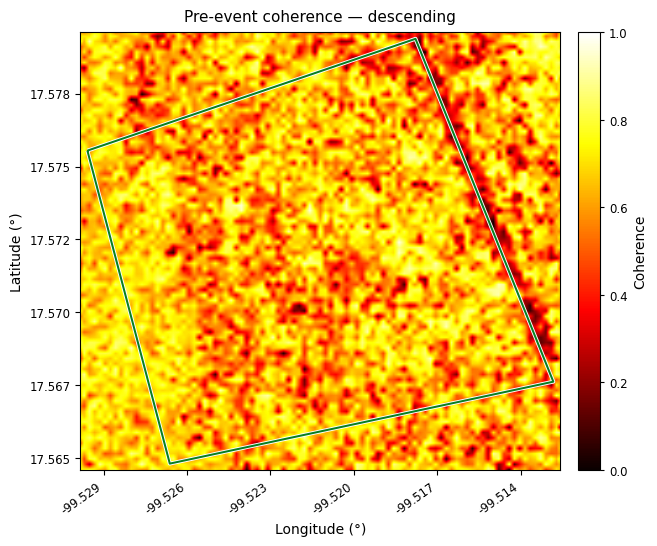

Guardado: coherence_pre_asc.png


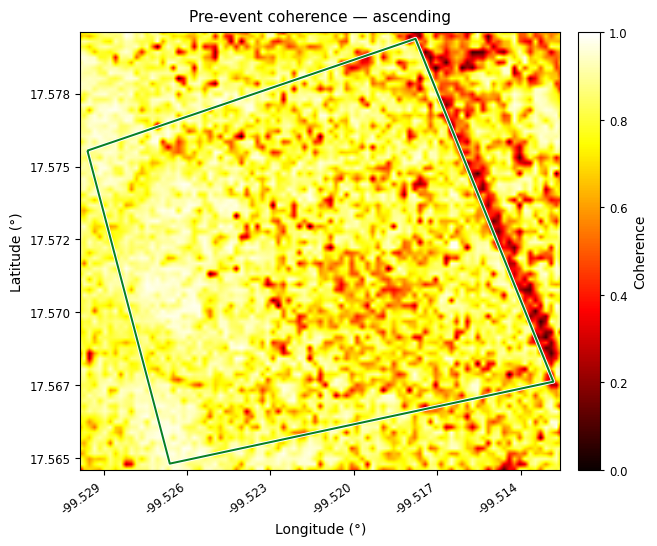

Guardado: coherence_event_desc.png


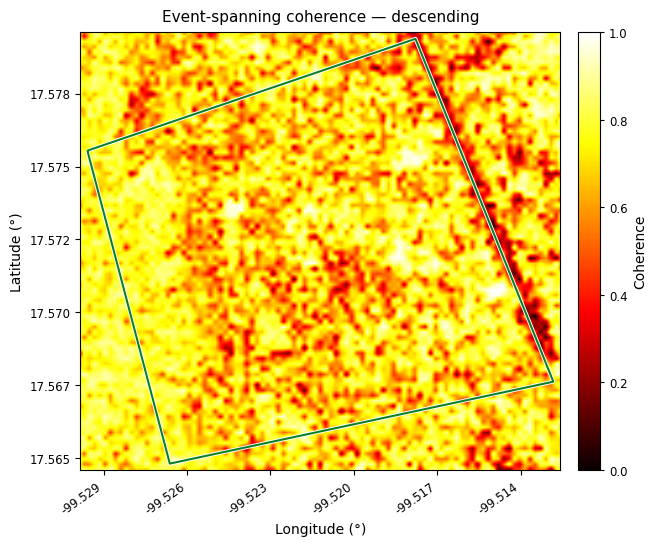

Guardado: coherence_event_asc.png


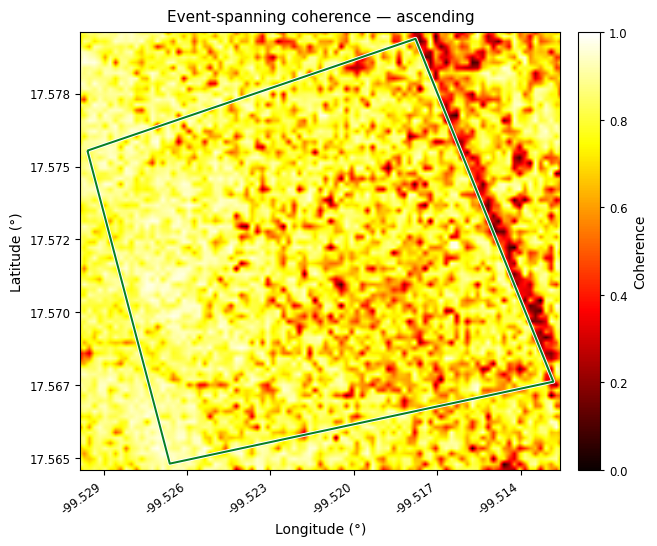

Guardado: pre_event_vertical_rate.png


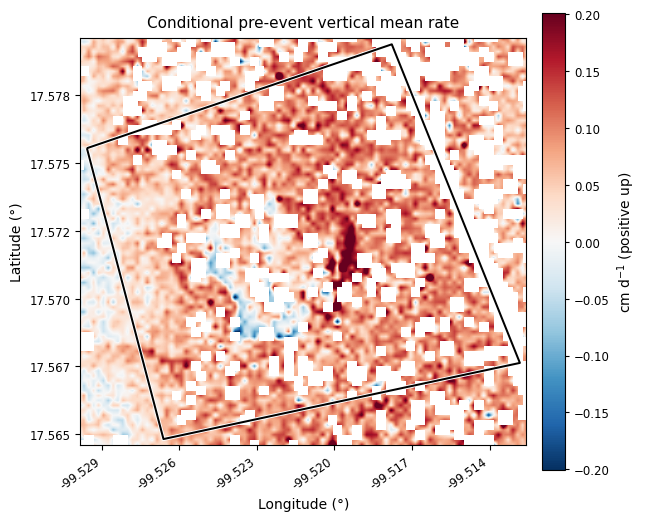

Guardado: pre_event_east_rate.png


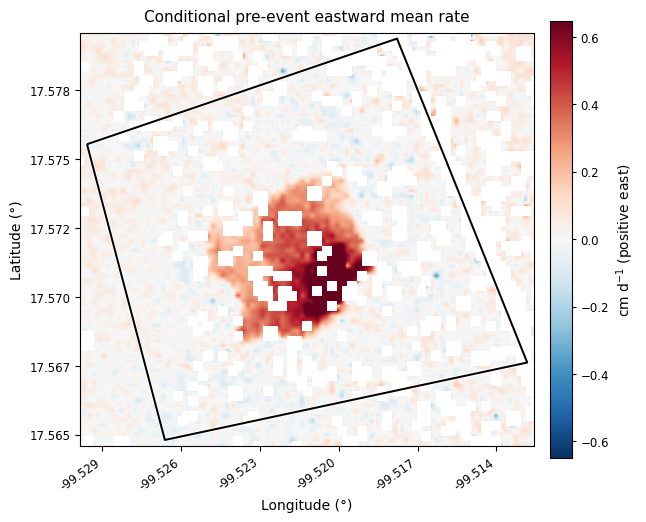

Guardado: event_spanning_vertical_displacement.png


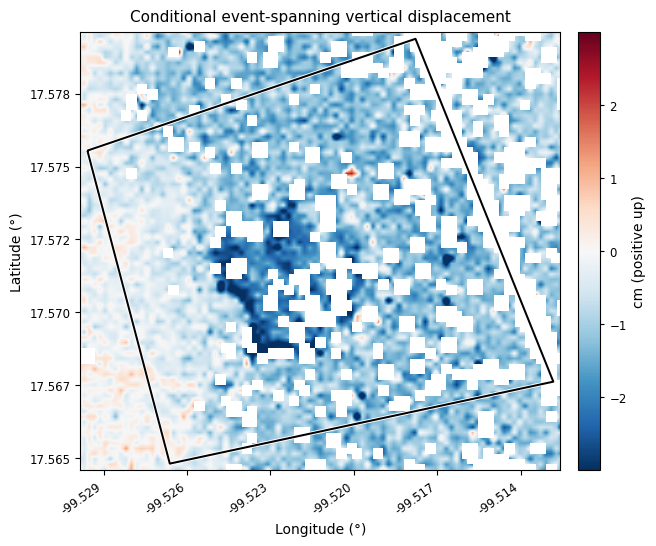

Guardado: event_spanning_east_displacement.png


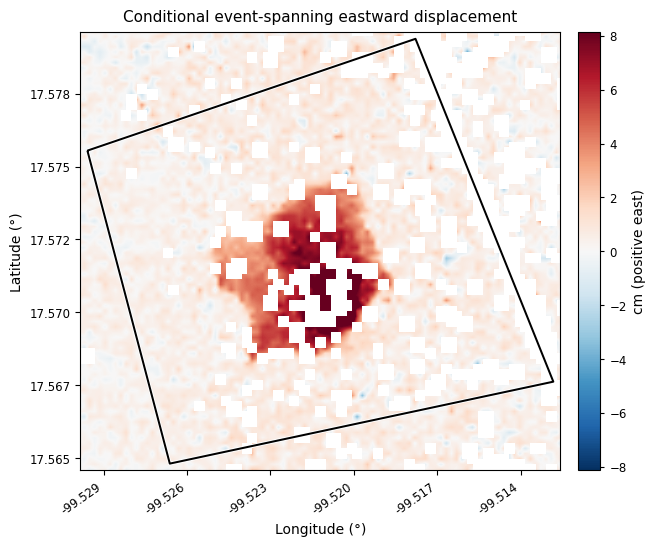

Figuras de publicación: /home/juanhuerta/Proyectos/Interferometry_Chilpancingo/Processing/Results/Figures


In [14]:
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from pyproj import Transformer


FIGURE_DIR = OUT_DIR / "Figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ROI_WGS84 = roi.to_crs(4326)
TO_WGS84 = Transformer.from_crs(CRS.from_epsg(EPSG), CRS.from_epsg(4326), always_xy=True)

PUBLICATION_STYLE = {
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "savefig.facecolor": "white",
}


def symmetric_limit(array, mask, percentile=98):
    values = np.asarray(array)[mask & np.isfinite(array)]
    if values.size == 0:
        return 1.0
    value = float(np.nanpercentile(np.abs(values), percentile))
    return value if np.isfinite(value) and value > 0 else 1.0


def geographic_image(product, field):
    x_min, x_max = float(np.min(product["x"])), float(np.max(product["x"]))
    y_min, y_max = float(np.min(product["y"])), float(np.max(product["y"]))
    corner_x = np.array([x_min, x_max, x_min, x_max])
    corner_y = np.array([y_min, y_min, y_max, y_max])
    longitude, latitude = TO_WGS84.transform(corner_x, corner_y)
    image = np.asarray(field)
    if product["y"][0] > product["y"][-1]:
        image = image[::-1, :]
    if product["x"][0] > product["x"][-1]:
        image = image[:, ::-1]
    extent = [float(np.min(longitude)), float(np.max(longitude)),
              float(np.min(latitude)), float(np.max(latitude))]
    return np.ma.masked_invalid(image), extent


def style_map_axes(ax, outline_color):
    lon_min, lat_min, lon_max, lat_max = ROI_WGS84.total_bounds
    pad_x = 0.015 * (lon_max - lon_min)
    pad_y = 0.015 * (lat_max - lat_min)
    ax.set_xlim(lon_min - pad_x, lon_max + pad_x)
    ax.set_ylim(lat_min - pad_y, lat_max + pad_y)
    ax.set_aspect(1.0 / np.cos(np.deg2rad(0.5 * (lat_min + lat_max))))
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=7))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.3f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
    ax.tick_params(width=0.8, length=3.5)
    for label in ax.get_xticklabels():
        label.set_rotation(35)
        label.set_horizontalalignment("right")
    # Halo blanco: el límite sigue visible sobre extremos claros y oscuros.
    ROI_WGS84.boundary.plot(ax=ax, color="white", linewidth=2.8, zorder=4)
    ROI_WGS84.boundary.plot(ax=ax, color=outline_color, linewidth=1.45, zorder=5)


def save_publication_figure(fig, stem):
    png_path = FIGURE_DIR / f"{stem}.png"
    fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0.04)
    print("Guardado:", png_path.name)


def plot_publication_map(product, field, *, title, stem, cmap, vmin, vmax,
                         colorbar_label, outline_color, extend="neither"):
    map_image, extent = geographic_image(product, field)
    colormap = plt.get_cmap(cmap).copy()
    colormap.set_bad("white")
    with plt.rc_context(PUBLICATION_STYLE):
        fig, ax = plt.subplots(figsize=(6.35, 5.35), constrained_layout=True)
        image = ax.imshow(
            map_image, extent=extent, origin="lower", aspect="auto",
            cmap=colormap, vmin=vmin, vmax=vmax, interpolation="bilinear",
            resample=True, rasterized=True,
        )
        style_map_axes(ax, outline_color)
        ax.set_title(title, pad=8)
        colorbar = fig.colorbar(image, ax=ax, pad=0.035, fraction=0.052, extend=extend)
        colorbar.set_label(colorbar_label)
        colorbar.ax.tick_params(width=0.8, length=3)
        save_publication_figure(fig, stem)
        plt.show()
        plt.close(fig)


COHERENCE_FIGURES = {
    "pre_desc": ("Pre-event coherence — descending", "coherence_pre_desc"),
    "pre_asc": ("Pre-event coherence — ascending", "coherence_pre_asc"),
    "event_desc": ("Event-spanning coherence — descending", "coherence_event_desc"),
    "event_asc": ("Event-spanning coherence — ascending", "coherence_event_asc"),
}
for pair_name, (title, stem) in COHERENCE_FIGURES.items():
    result = processed[pair_name]
    plot_publication_map(
        result, result["coherence"], title=title, stem=stem, cmap="hot",
        vmin=0.0, vmax=1.0, colorbar_label="Coherence", outline_color="#087f23",
    )


COMPONENT_FIGURES = [
    (pre_2d, "up_context", "Conditional pre-event vertical mean rate",
     "pre_event_vertical_rate", "cm d$^{-1}$ (positive up)"),
    (pre_2d, "east_context", "Conditional pre-event eastward mean rate",
     "pre_event_east_rate", "cm d$^{-1}$ (positive east)"),
    (event_2d, "up_context", "Conditional event-spanning vertical displacement",
     "event_spanning_vertical_displacement", "cm (positive up)"),
    (event_2d, "east_context", "Conditional event-spanning eastward displacement",
     "event_spanning_east_displacement", "cm (positive east)"),
]
for product, field_name, title, stem, units in COMPONENT_FIGURES:
    field = product[field_name]
    limit = symmetric_limit(field, product["roi"])
    plot_publication_map(
        product, field, title=title, stem=stem, cmap="RdBu_r",
        vmin=-limit, vmax=limit, colorbar_label=units, outline_color="black",
    )

print(f"Figuras de publicación: {FIGURE_DIR}")


## 12b. Archived execution snapshot

The following values were read from the NetCDF and QA files produced by the source notebook on 14 August 2026. They are retained so that the processing outcome is understandable even when the external GSLC archive is unavailable. Re-execution may change them if inputs, corrections, reference areas, DEM, or software versions change. Because the archived execution used height-layer-averaged LOS geometry and candidate reference pixels, the following east/up statistics describe a conditional diagnostic solution and not a validated geodetic measurement.

| Pair | Mean ROI coherence | ROI fraction $\gamma\geq0.30$ | Median ramp-sensitivity SD (cm) |
|---|---:|---:|---:|
| Pre-event descending | 0.624 | 0.954 | 0.0012 |
| Pre-event ascending | 0.783 | 0.987 | 0.0175 |
| Event-spanning descending | 0.694 | 0.972 | 0.0130 |
| Event-spanning ascending | 0.758 | 0.982 | 0.0076 |

Median absolute wrapped closure is 0.113 rad (descending) and 0.062 rad (ascending). The conditional event-spanning solution has a median east component of 0.65 cm and a median up component of −1.12 cm over 4,162 finite ROI pixels; its 2nd–98th percentile ranges are −0.62 to 8.12 cm east and −3.00 to 0.32 cm up. These descriptive statistics are **not earthquake-effect estimates**. The east/up system has a median condition number of 1.070 after fixing north to zero. A real 1 cm northward displacement would bias the median solution by about −0.028 cm east and +0.238 cm up. These descriptive statistics are not estimates of earthquake-induced deformation and must not be interpreted as evidence of a causal earthquake effect.

| Pre-event coherence | Event-spanning coherence |
|---|---|
| ![Pre-event descending coherence](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/coherence_pre_desc.png) | ![Event-spanning descending coherence](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/coherence_event_desc.png) |
| ![Pre-event ascending coherence](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/coherence_pre_asc.png) | ![Event-spanning ascending coherence](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/coherence_event_asc.png) |

| Conditional pre-event proxies | Conditional event-spanning proxies |
|---|---|
| ![Pre-event eastward mean rate](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/pre_event_east_rate.png) | ![Event-spanning eastward displacement](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/event_spanning_east_displacement.png) |
| ![Pre-event vertical mean rate](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/pre_event_vertical_rate.png) | ![Event-spanning vertical displacement](/Users/juanhuerta/Documents/Projects/Chilpancingo_project/Publication/Processing/Results/Figures/event_spanning_vertical_displacement.png) |


## 13. Products and interpretation boundary

The workflow produces:

- a polygon-preserving subset with explicit spatial context;
- four GSLC interferograms with tested phase and LOS sign conventions;
- beta0, moment-based coherence, validity and connected-component masks;
- masked unwrapped phase without zero-filled gaps;
- a post-unwrapping robust planar correction with reference sensitivity;
- relative LOS displacement and exact interval-mean rate;
- spatially interpolated LOS geometry derived from the metadata cube; when no ellipsoidal DEM is supplied, the geometry is approximated by averaging the metadata-cube height layers;
- diagnostics for coherence threshold, closure, geometry conditioning, omitted north
  motion, reference sensitivity, and nominal decorrelation precision.

The notebook is suitable for publication in a repository as an exploratory, reproducible technical workflow for evaluating the operational potential of six NISAR BETA GSLC products. It produces relative LOS displacement and apparent interval-mean LOS-rate maps, together with processing and sensitivity diagnostics.
The outputs are not validated earthquake-deformation products and do not isolate coseismic or postseismic motion. Quantitative geodetic interpretation or causal attribution would require, at minimum, a demonstrably stable common reference, ellipsoidal-DEM interpolation of the LOS geometry, correction or assessment of propagation and orbital errors, validation of phase unwrapping, a systematic uncertainty budget, a longer temporal series, and independent observations such as temporally compatible GNSS measurements.


## References

### Mission and event documentation

1. NISAR Science Data System, [Geocoded Single Look Complex (GSLC) User Guide](https://nisar-docs.asf.alaska.edu/gslc/).
2. NISAR Science Data System, [Metadata cubes](https://nisar-docs.asf.alaska.edu/metadata/) and [LOS-vector definitions](https://nisar-docs.asf.alaska.edu/glossary/).
3. NISAR Science Data System, [Pre-calibration product known issues](https://nisar-docs.asf.alaska.edu/product-known-issues/) and [PROVISIONAL product status](https://nisar-docs.asf.alaska.edu/provisional-known-issues/).
4. NISAR Science Data System, [Geocoded Unwrapped Interferogram (GUNW) User Guide](https://nisar-docs.asf.alaska.edu/gunw/).
5. ISCE3, [`Crossmul.cpp`](https://github.com/isce-framework/isce3/blob/develop/cxx/isce3/signal/Crossmul.cpp), reference-times-conjugate-secondary implementation.
6. Servicio Sismológico Nacional, UNAM, [Special report: Earthquakes of 2 January 2026, Guerrero (M 6.5)](https://www.ssn.unam.mx/sismicidad/reportes-especiales/2026/SSNMX_rep_esp_20260102_Guerrero_M65.pdf).

### Methods

7. Bamler, R., & Hartl, P. (1998). Synthetic aperture radar interferometry. *Inverse Problems, 14*, R1–R54. [doi:10.1088/0266-5611/14/4/001](https://doi.org/10.1088/0266-5611/14/4/001).
8. Rosen, P. A., et al. (2000). Synthetic aperture radar interferometry. *Annual Review of Earth and Planetary Sciences, 28*, 169–209. [doi:10.1146/annurev.earth.28.1.169](https://doi.org/10.1146/annurev.earth.28.1.169).
9. Rodriguez, E., & Martin, J. M. (1992). Theory and design of interferometric synthetic aperture radars. *IEE Proceedings F, 139*, 147–159. [doi:10.1049/ip-f-2.1992.0018](https://doi.org/10.1049/IP-F-2.1992.0018).
10. Herráez, M. A., et al. (2002). Fast two-dimensional phase-unwrapping algorithm based on sorting by reliability following a noncontinuous path. *Applied Optics, 41*, 7437–7444. [doi:10.1364/AO.41.007437](https://doi.org/10.1364/AO.41.007437).
11. Huber, P. J. (1964). Robust estimation of a location parameter. *Annals of Mathematical Statistics, 35*, 73–101. [doi:10.1214/aoms/1177703732](https://doi.org/10.1214/aoms/1177703732).
12. Wright, T. J., Parsons, B. E., & Lu, Z. (2004). Toward mapping surface deformation in three dimensions using InSAR. *Geophysical Research Letters, 31*, L01607. [doi:10.1029/2003GL018827](https://doi.org/10.1029/2003GL018827).
13. Fuhrmann, T., & Garthwaite, M. C. (2019). Resolving three-dimensional surface motion with InSAR: Constraints from multi-geometry data fusion. *Remote Sensing, 11*, 241. [doi:10.3390/rs11030241](https://doi.org/10.3390/rs11030241).
14. Ma, P., et al. (2022). Go Extra Miles: An additional error correction procedure aimed to further improve phase unwrapping accuracy and reduce creep model uncertainty. *Journal of Geophysical Research: Solid Earth, 127*. [doi:10.1029/2021JB022478](https://doi.org/10.1029/2021JB022478).
